<a href="https://colab.research.google.com/github/Ebrahim-khewani/Test/blob/ai/bulid_ai_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import seaborn as sns

In [82]:
# Google Sheets file ID
file_id = "1PrCBjpZsSl7l2YJ_LzJvNhd4rJybCx1FDjSUkV8xfdM"

# Construct the CSV download URL
csv_url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv"

# Read the CSV into a DataFrame
df = pd.read_csv(csv_url)

# Display the DataFrame




In [83]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [84]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [86]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [87]:
df['sex'].value_counts()

,count
sex,
male,676
female,662


In [88]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [89]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


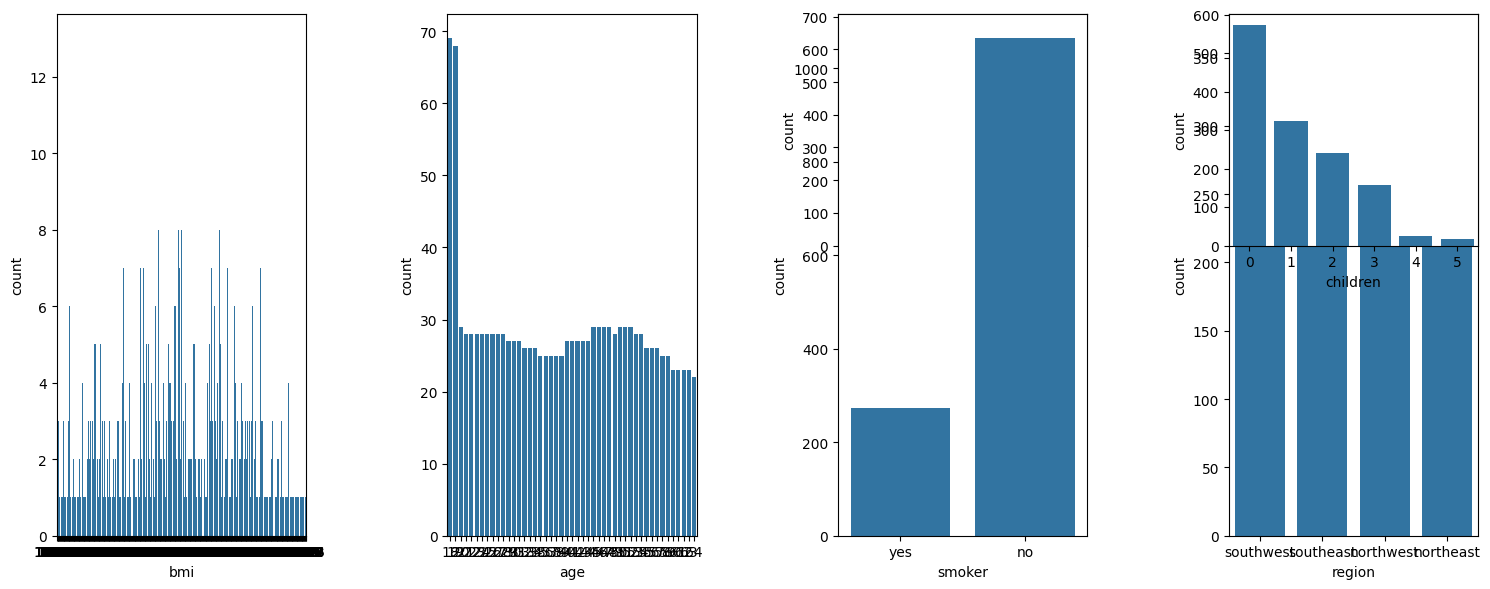

In [90]:
plt.figure(figsize=(15,6))


plt.subplot(1,4,1)
sns.countplot(x='bmi', data=df)


plt.subplot(2,4,3)
sns.countplot(x='sex', data=df)

plt.subplot(1,4,3)
sns.countplot(x='smoker', data=df)

plt.subplot(1,4,4)
sns.countplot(x='region', data=df)


plt.subplot(1,4,2)
sns.countplot(x='age', data=df)

plt.subplot(2,4,4)
sns.countplot(x='children', data=df)


plt.tight_layout()
plt.show()


In [91]:

df['sex'] = df['sex'].replace({'male': 0, 'female': 1})


df['smoker'] = df['smoker'].replace({'no': 0, 'yes': 1})

df['region'] = df['region'].replace({'southeast':0 , 'southwest':1 ,'northwest': 2, 'northeast':3 })

<ipython-input-91-150da6adbc49>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'male': 0, 'female': 1})
<ipython-input-91-150da6adbc49>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'] = df['smoker'].replace({'no': 0, 'yes': 1})
<ipython-input-91-150da6adbc49>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.

In [92]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,2,10600.54830
1334,18,1,31.920,0,0,3,2205.98080
1335,18,1,36.850,0,0,0,1629.83350
1336,21,1,25.800,0,0,1,2007.94500


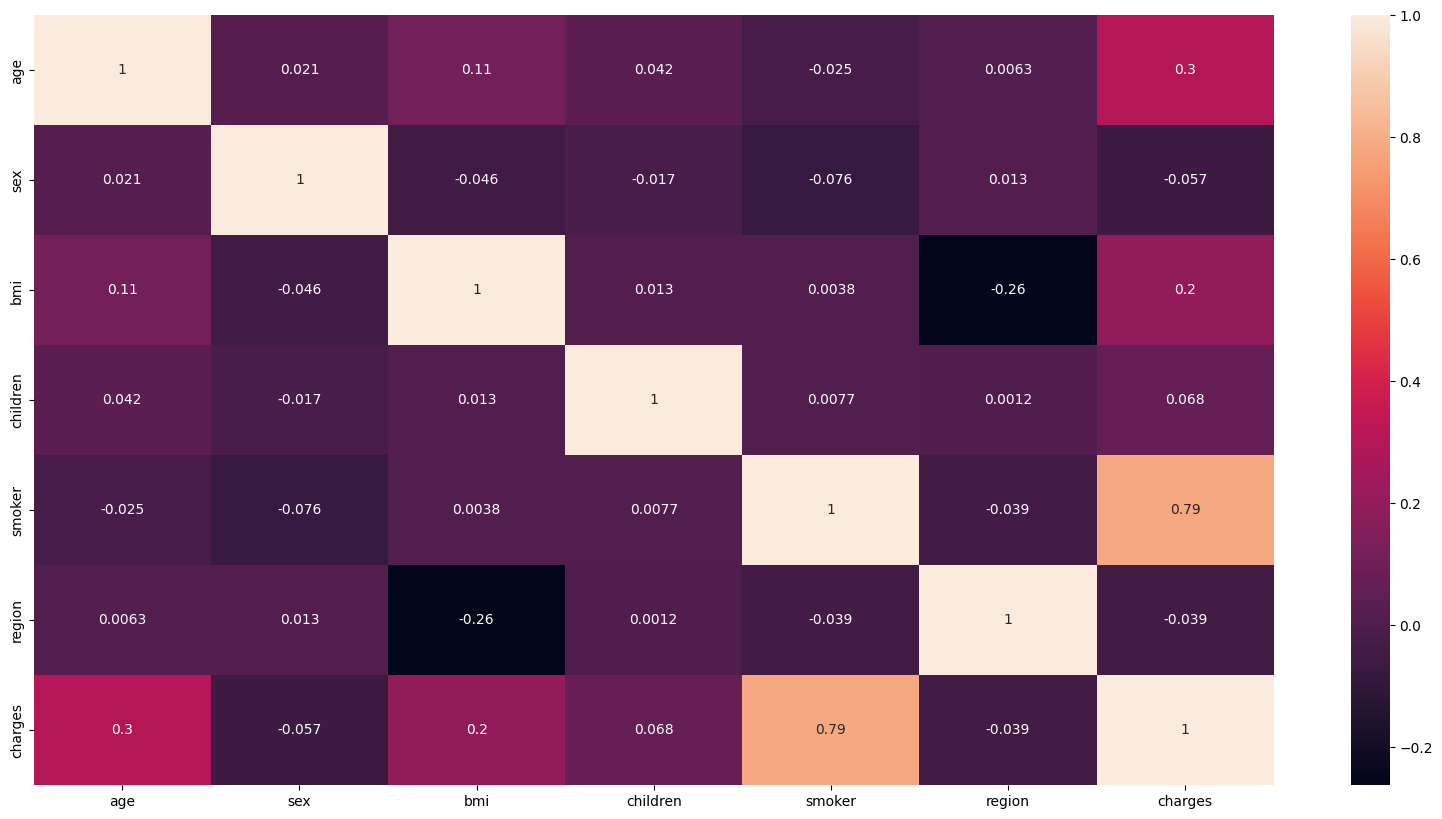

In [93]:

insurance_df=df[['age','sex','bmi','children','smoker','region','charges']]

#insurance_df=df[['age','bmi','children','charges']]

corrMatrix = insurance_df.corr()
f, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(corrMatrix, annot = True)
plt.show()


In [94]:
insur = df.drop('charges',axis=1)

insur_lable = df['charges']




In [95]:
insur

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,1,1
1,18,0,33.770,1,0,0
2,28,0,33.000,3,0,0
3,33,0,22.705,0,0,2
4,32,0,28.880,0,0,2
...,...,...,...,...,...,...
1333,50,0,30.970,3,0,2
1334,18,1,31.920,0,0,3
1335,18,1,36.850,0,0,0
1336,21,1,25.800,0,0,1


In [96]:
insur = insur.astype(int)

In [97]:
insur_lable

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [98]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(insur,insur_lable, test_size=0.2, random_state=42)


In [99]:
#for set_ in (train_set, test_set):
#    set_.drop("charges", axis=1, inplace=True)

In [100]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [101]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Scikit-learn Model:")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

X_train_sm = sm.add_constant(X_train) # Add a constant (intercept) to the model
# create a first fitted model
lr_model = sm.OLS(y_train, X_train_sm).fit()

print("\nStatsmodels Summary:")
print(lr_model.summary())

new_data = pd.DataFrame([[19, 1, 27.900, 0, 1, 1]], columns=insur.columns)
new_prediction = model.predict(new_data)
print(f"\nPrediction for new data: {new_prediction}")


Scikit-learn Model:
Mean Squared Error: 33517342.19601738
R-squared: 0.7841055326252798

Statsmodels Summary:
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     508.1
Date:                Thu, 23 Jan 2025   Prob (F-statistic):          4.33e-308
Time:                        14:27:21   Log-Likelihood:                -10846.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1063   BIC:                         2.174e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [129]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor

In [130]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,0.298584
1,18,0,33.770,1,0,0,-0.953689
2,28,0,33.000,3,0,0,-0.728675
3,33,0,22.705,0,0,2,0.719843
4,32,0,28.880,0,0,2,-0.776802


In [128]:
scaler = StandardScaler()
columns_to_scale = ['charges']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [164]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,0.298584
1,18,0,33.770,1,0,0,-0.953689
2,28,0,33.000,3,0,0,-0.728675
3,33,0,22.705,0,0,2,0.719843
4,32,0,28.880,0,0,2,-0.776802
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,2,-0.220551
1334,18,1,31.920,0,0,3,-0.914002
1335,18,1,36.850,0,0,0,-0.961596
1336,21,1,25.800,0,0,1,-0.930362


In [168]:
X = df.drop(['charges'] , axis=1)
y = df['charges']

In [169]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=.20 , random_state=42)

X_train.shape , X_test.shape , y_train.shape , y_test.shape

((1070, 6), (268, 6), (1070,), (268,))

In [172]:
model_rand = RandomForestRegressor(n_estimators=100, max_depth=15 , random_state=42,
                         min_samples_split=10
                        ,min_samples_leaf=10)

k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_rand, X_train , y_train, cv=k_folds)

print("K-Fold Cross-Validation Scores:", scores)

mean_accuracy = np.mean(scores)
print("Mean Accuracy:", mean_accuracy)
print('-------------------------')



K-Fold Cross-Validation Scores: [0.82013492 0.85188815 0.90242009 0.83381488 0.87384221]
Mean Accuracy: 0.8564200499137451
-------------------------


In [173]:
model_rand.fit(X_train , y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=10, min_samples_split=10,
                      random_state=42)

,age,sex,bmi,children,smoker,region
764,45,1,25.175,2,0,3
887,36,1,30.020,0,0,2
890,64,1,26.885,0,1,2
1293,46,0,25.745,3,0,2
259,19,0,31.920,0,1,2
...,...,...,...,...,...,...
109,63,0,35.090,0,1,0
575,58,1,27.170,0,0,2
535,38,0,28.025,1,0,3
543,54,1,47.410,0,1,0


In [174]:
model_rand.score(X_train , y_train)

0.8879673250638537

In [175]:
y_pred = model_rand.predict(X_test)

In [176]:

r2_score(y_test , y_pred)

0.8780074309588416

In [177]:
mean_absolute_error(y_test , y_pred)

0.20275768231030822

In [178]:
mean_squared_error(y_test , y_pred)

0.1292400303900111

In [179]:
new_data = pd.DataFrame([[18, 0, 33.770, 1, 0, 0]], columns=X.columns)
new_prediction = model_rand.predict(new_data)
print(f"\nPrediction for new data: {new_prediction}")


Prediction for new data: [-0.72990665]
